# Re-evaluating the dissertation models without data leakage

**Author:** Jeremiah Dibie · re-analysis of my MSc dissertation (2024)

My dissertation reported up to **99.2% accuracy** for detecting ASD risk from the Q-CHAT questionnaire. When I went back over the original notebook (`01_original_dissertation_analysis.ipynb`), I found two problems in the evaluation that made those numbers far too optimistic:

1. **Label leakage through `group`.** The `group` column (diagnostic group) maps one-to-one onto the target `asd_risk`, so any model that sees it can simply read off the answer.
2. **SMOTE before the train/test split.** Oversampling the whole dataset first put synthetic copies of minority cases into the test set, so models were partly tested on data derived from their own training examples.

This notebook measures the effect of each problem, then re-runs the model comparison properly:
- `group` (and `child_ID`) removed from the features
- SMOTE and scaling inside an `imblearn` pipeline, so they are fitted on training folds only
- evaluation on the original, **imbalanced** data with metrics suited to rare outcomes (ROC AUC, precision-recall AUC, recall, balanced accuracy)

**Data:** `Qchat_Full_Polish_Cleaned.csv` (1,016 toddlers; Niedźwiecka & Pisula, 2022), placed in `../data/`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RepeatedStratifiedKFold, cross_validate, cross_val_predict)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

SEED = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 90

## 1. Load the data

In [2]:
df = pd.read_csv("../data/Qchat_Full_Polish_Cleaned.csv", encoding="utf-8-sig")
df = df.drop(columns="child_ID")
df["asd_risk"] = (df["asd_risk"] == 2).astype(int)   # 1 = high risk, 0 = low risk

print(df.shape)
print(df["asd_risk"].value_counts().rename({0: "low risk", 1: "high risk"}))
print(f"High-risk prevalence: {df['asd_risk'].mean():.1%}")

(1016, 30)
asd_risk
low risk     949
high risk     67
Name: count, dtype: int64
High-risk prevalence: 6.6%


## 2. Problem 1: `group` gives the answer away

The cross-tab below shows that every child in group 2 is high risk and every child in the other groups is low risk. `group` *is* the label, recorded in a different column.

In [3]:
pd.crosstab(df["group"], df["asd_risk"], margins=True)

asd_risk,0,1,All
group,,,
1,250,0,250
2,0,67,67
3,120,0,120
4,579,0,579
All,949,67,1016


In [4]:
# A one-line rule, with no machine learning at all, is "perfect"
rule_pred = (df["group"] == 2).astype(int)
print(f"Accuracy of the rule 'group == 2': {accuracy_score(df['asd_risk'], rule_pred):.3f}")

Accuracy of the rule 'group == 2': 1.000


The total Q-CHAT score, by contrast, barely differs between the two classes. The questionnaire on its own is a much harder problem than the original results suggested:

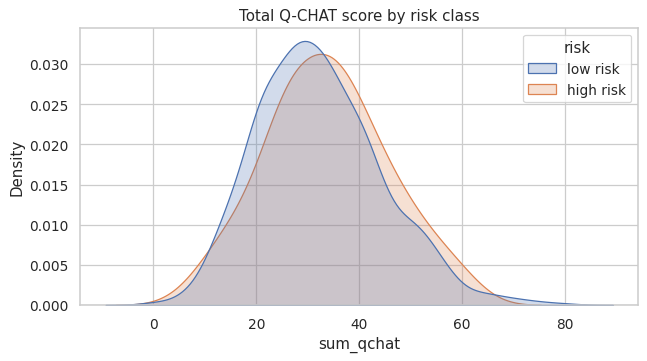

,count,mean,std,min,25%,50%,75%,max
asd_risk,,,,,,,,
0,949.0,32.163330,12.159787,0.0,23.0,31.0,40.0,80.0
1,67.0,33.716418,11.797285,8.0,26.0,34.0,41.5,60.0


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = df.assign(risk=df["asd_risk"].map({0: "low risk", 1: "high risk"}))
sns.kdeplot(data=plot_df, x="sum_qchat", hue="risk", common_norm=False, fill=True, ax=ax)
ax.set_title("Total Q-CHAT score by risk class")
ax.set_xlabel("sum_qchat")
plt.show()
df.groupby("asd_risk")["sum_qchat"].describe()

## 3. How much did each problem inflate the results?

Same SVM, four set-ups. "SMOTE before split" copies the original notebook: oversample everything, then split 80/20. "SMOTE in pipeline" splits first, oversamples only the training data, and tests on real, imbalanced cases.

In [6]:
def smote_before_split(X, y, model):
    Xs, ys = SMOTE(random_state=SEED).fit_resample(X, y)
    X_tr, X_te, y_tr, y_te = train_test_split(Xs, ys, test_size=0.2, stratify=ys, random_state=SEED)
    sc = StandardScaler().fit(X_tr)
    model.fit(sc.transform(X_tr), y_tr)
    p = model.predict_proba(sc.transform(X_te))[:, 1]
    return y_te, p

def smote_in_pipeline(X, y, model):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    pipe = Pipeline([("scale", StandardScaler()), ("smote", SMOTE(random_state=SEED)), ("model", model)])
    pipe.fit(X_tr, y_tr)
    return y_te, pipe.predict_proba(X_te)[:, 1]

y = df["asd_risk"]
feature_sets = {
    "with group": df.drop(columns="asd_risk"),
    "without group": df.drop(columns=["asd_risk", "group"]),
}

rows = []
for fs_name, X in feature_sets.items():
    for setup_name, fn in [("SMOTE before split", smote_before_split), ("SMOTE in pipeline", smote_in_pipeline)]:
        y_te, p = fn(X, y, SVC(probability=True, random_state=SEED))
        pred = (p >= 0.5).astype(int)
        rows.append({"features": fs_name, "set-up": setup_name, "test positives": int(y_te.sum()),
                     "accuracy": accuracy_score(y_te, pred), "recall": recall_score(y_te, pred),
                     "precision": precision_score(y_te, pred, zero_division=0),
                     "ROC AUC": roc_auc_score(y_te, p)})
leak_table = pd.DataFrame(rows).round(3)
leak_table

,features,set-up,test positives,accuracy,recall,precision,ROC AUC
0,with group,SMOTE before split,190,0.979,0.979,0.979,0.999
1,with group,SMOTE in pipeline,13,0.926,0.077,0.250,0.874
2,without group,SMOTE before split,190,0.976,0.963,0.989,0.997
3,without group,SMOTE in pipeline,13,0.926,0.077,0.250,0.715


**SMOTE before the split is the main culprit.** Even without `group` (row 3) it produces near-perfect scores. The synthetic test cases are interpolations between minority-class training points, so they are trivially easy to classify. Once SMOTE moves inside the pipeline (rows 2 and 4), recall at the default 0.5 threshold collapses. Removing `group` as well brings ROC AUC down to about 0.72, which is what the questionnaire can actually do. (The 13-positive test set is small, so section 4 uses repeated cross-validation instead.)

## 4. Corrected model comparison

Features: sex, age, total Q-CHAT score and the 25 individual items. Every model runs inside the same pipeline (scale → SMOTE → model). With only 67 high-risk children, a single 20% test set holds about 13 positives, which is too few for stable numbers. So the main estimate is **5-fold stratified cross-validation repeated 5 times** (25 fits per model).

In [7]:
X = df.drop(columns=["asd_risk", "group"])

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=SEED),
    "SVM": SVC(probability=True, random_state=SEED),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=SEED),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}
base_models["Stacking"] = StackingClassifier(
    estimators=[(n.replace(" ", "_"), m) for n, m in base_models.items()],
    final_estimator=LogisticRegression(max_iter=5000), cv=5)

def make_pipe(model):
    return Pipeline([("scale", StandardScaler()), ("smote", SMOTE(random_state=SEED)), ("model", model)])

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)
scoring = {"ROC AUC": "roc_auc", "PR AUC": "average_precision", "recall": "recall",
           "precision": "precision", "balanced acc.": "balanced_accuracy", "accuracy": "accuracy"}

results = {}
for name, model in base_models.items():
    r = cross_validate(make_pipe(model), X, y, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {k: r[f"test_{v}"].mean() for k, v in
                     {"ROC AUC": "ROC AUC", "PR AUC": "PR AUC", "recall": "recall", "precision": "precision",
                      "balanced acc.": "balanced acc.", "accuracy": "accuracy"}.items()}
    results[name]["ROC AUC sd"] = r["test_ROC AUC"].std()

cv_table = pd.DataFrame(results).T.sort_values("ROC AUC", ascending=False).round(3)
print(f"Chance level for PR AUC = prevalence = {y.mean():.3f}")
cv_table

Chance level for PR AUC = prevalence = 0.066


,ROC AUC,PR AUC,recall,precision,balanced acc.,accuracy,ROC AUC sd
Random Forest,0.772,0.238,0.085,0.390,0.537,0.930,0.050
SVM,0.746,0.208,0.179,0.190,0.563,0.895,0.062
Logistic Regression,0.746,0.217,0.599,0.145,0.676,0.743,0.054
KNN,0.744,0.157,0.818,0.122,0.701,0.598,0.053
Gradient Boosting,0.739,0.229,0.123,0.293,0.550,0.921,0.059
Decision Tree,0.687,0.135,0.460,0.144,0.632,0.780,0.056
Stacking,0.641,0.194,0.058,0.267,0.524,0.928,0.064


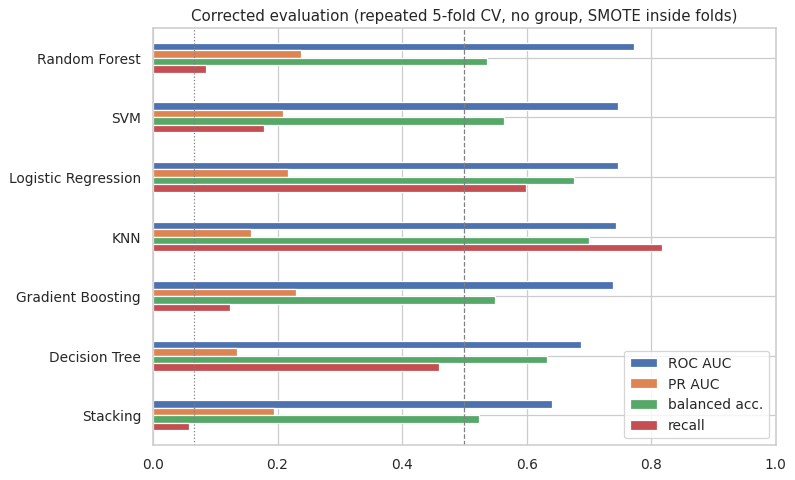

In [8]:
ax = cv_table[["ROC AUC", "PR AUC", "balanced acc.", "recall"]].plot.barh(figsize=(9, 5.5))
ax.axvline(0.5, color="grey", ls="--", lw=1)
ax.axvline(y.mean(), color="grey", ls=":", lw=1)
ax.set_title("Corrected evaluation (repeated 5-fold CV, no group, SMOTE inside folds)")
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../images/corrected_model_comparison.png", dpi=110)
plt.show()

## 5. ROC and precision-recall curves

Out-of-fold predicted probabilities (5-fold CV) for the three strongest models. The precision-recall curve is the more honest view when only 6.6% of children are high risk.

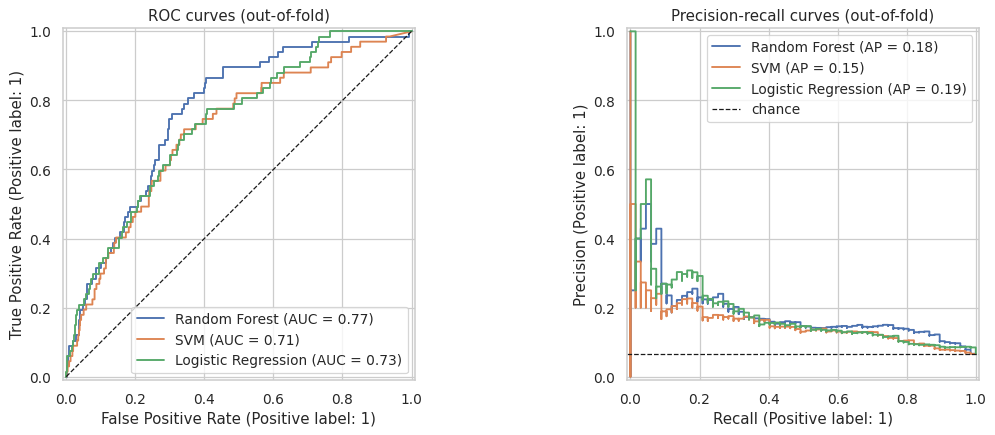

In [9]:
top3 = cv_table.index[:3]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = {n: cross_val_predict(make_pipe(base_models[n]), X, y, cv=skf, method="predict_proba")[:, 1] for n in top3}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for n, p in oof.items():
    RocCurveDisplay.from_predictions(y, p, name=n, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y, p, name=n, ax=axes[1])
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC curves (out-of-fold)")
axes[1].axhline(y.mean(), color="k", ls="--", lw=1, label="chance")
axes[1].set_title("Precision-recall curves (out-of-fold)")
axes[1].legend()
plt.tight_layout()
plt.savefig("../images/corrected_roc_pr_curves.png", dpi=110)
plt.show()

## 6. What would this mean as a screening tool?

For screening, missing a high-risk child costs more than a false alarm. So instead of the default 0.5 cut-off, choose the threshold that catches at least **80% of high-risk children**, then see how many low-risk children get flagged as a result.

Model: Random Forest  |  threshold = 0.149
Recall (sensitivity): 80.6%  ->  54 of 67 high-risk children caught
Specificity:          64.7%
Precision (PPV):      13.9%  ->  335 low-risk children flagged for follow-up


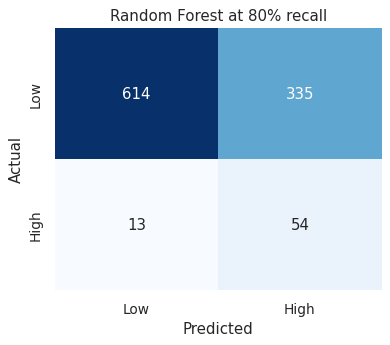

In [10]:
best = cv_table.index[0]
p = oof[best]
thresholds = np.sort(np.unique(p))[::-1]
for t in thresholds:
    if recall_score(y, (p >= t).astype(int)) >= 0.80:
        break
pred = (p >= t).astype(int)
tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
print(f"Model: {best}  |  threshold = {t:.3f}")
print(f"Recall (sensitivity): {tp/(tp+fn):.1%}  ->  {tp} of {tp+fn} high-risk children caught")
print(f"Specificity:          {tn/(tn+fp):.1%}")
print(f"Precision (PPV):      {tp/(tp+fp):.1%}  ->  {fp} low-risk children flagged for follow-up")

fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(confusion_matrix(y, pred), annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Low", "High"], yticklabels=["Low", "High"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"{best} at 80% recall")
plt.tight_layout()
plt.show()

## 7. Which questions carry real signal?

Standardised logistic regression coefficients, averaged over 25 cross-validation fits, show which inputs move a prediction towards (red) or away from (blue) high risk. `sum_qchat` is left out here because it is the exact sum of Q01–Q25, so including it would split the effect arbitrarily between the total and the items. The error bars show how stable each coefficient is.

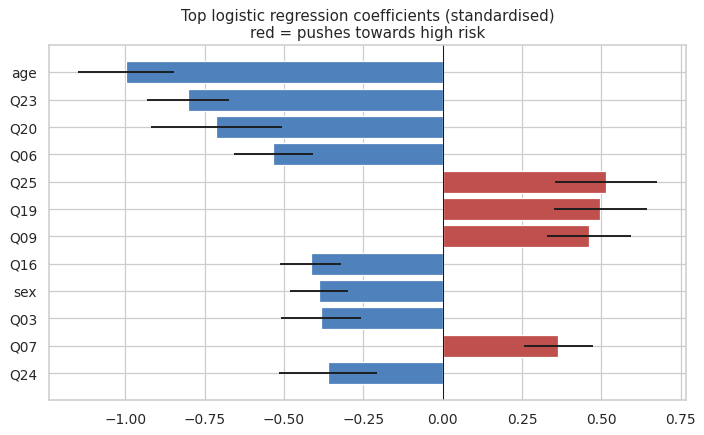

,mean,sd
age,-0.998,0.151
Q23,-0.803,0.129
Q20,-0.713,0.206
Q06,-0.534,0.124
Q25,0.515,0.161
Q19,0.497,0.147
Q09,0.460,0.133
Q16,-0.416,0.096
sex,-0.390,0.092
Q03,-0.383,0.125


In [11]:
X_items = X.drop(columns="sum_qchat")
coefs = []
for tr, _ in cv.split(X_items, y):
    pipe = make_pipe(LogisticRegression(max_iter=5000, random_state=SEED)).fit(X_items.iloc[tr], y.iloc[tr])
    coefs.append(pipe.named_steps["model"].coef_[0])
coef = pd.DataFrame(coefs, columns=X_items.columns)
summary = pd.DataFrame({"mean": coef.mean(), "sd": coef.std()})
top = summary.reindex(summary["mean"].abs().sort_values(ascending=False).index).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index[::-1], top["mean"][::-1], xerr=top["sd"][::-1],
        color=["#c0504d" if v > 0 else "#4f81bd" for v in top["mean"][::-1]])
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Top logistic regression coefficients (standardised)\nred = pushes towards high risk")
plt.tight_layout()
plt.savefig("../images/corrected_feature_effects.png", dpi=110)
plt.show()
top.round(3)

## 8. Summary

| | Dissertation (2024) | Corrected re-evaluation |
|---|---|---|
| Features | incl. `group` | `group` removed |
| SMOTE | whole dataset, before split | training folds only |
| Test data | balanced, partly synthetic | real, imbalanced (6.6% high risk) |
| Headline | 99.2% accuracy, ROC AUC 0.999 (SVM) | ROC AUC ≈ 0.75 for the best models; PR AUC ≈ 0.21–0.24 against 0.066 chance |

**What I take from this**

- The near-perfect scores came from the evaluation design, not from the models. `group` leaked the label, and SMOTE before the split leaked synthetic copies of minority cases into the test set.
- Without leakage, the questionnaire still carries **real but modest signal** (ROC AUC clearly above 0.5). It is a starting point for screening, not a diagnostic tool.
- Accuracy is the wrong headline metric at 6.6% prevalence. A model that always predicts "low risk" scores 93% accuracy. PR AUC, recall at a fixed threshold, and balanced accuracy tell the real story.
- This is exactly the kind of failure that makes ML untrustworthy in healthcare. It is also why I am interested in how data handling (oversampling, poisoning, label quality) can silently distort what a model learns.